## Configuration

In [1]:
# # New York City, New York
# STATE="NY"

# COUNTIES = [
#     "005",  # Bronx
#     "047",  # Brooklyn (Kings County)
#     "061",  # Manhattan
#     "081",  # Queens
#     "085"   # Staten Island (Richmond County)
# ]

# YEAR = 2023

# # # Denver, Colorado
# # STATE = "CO"

# # COUNTIES = [
# #     "031",  # Denver County
# # ]

# YEAR = 2023

In [2]:
# Configuration
CITY = "atlanta"
YEAR = 2023

CITY_CONFIGS = {
"new_york": {
        "state": "NY",
        "counties": [
            "005",  # Bronx
            "047",  # Brooklyn (Kings)
            "061",  # Manhattan
            "081",  # Queens
            "085"   # Staten Island
        ],
        "osm_pbf":
            "../data/city_data/new_york/new-york-260512.osm.pbf",
        "gtfs": [
            "../data/city_data/new_york/gtfs_subway.zip"
        ]
    },

    "boston": {
        "state": "MA",
        "counties": [
            "025",  # Suffolk
            # "009",  # Essex
            # "017",  # Middlesex
            # "021",  # Norfolk
            # "023"   # Plymouth
        ],
        "osm_pbf":
            "../data/city_data/boston/massachusetts-260524.osm.pbf",
        "gtfs": [
            "../data/city_data/boston/MBTA_GTFS.zip"
        ]
    },

    "washington_dc": {
        "state": "DC",
        "counties": [
            "001"
        ],
        "osm_pbf":
            "../data/city_data/washington_dc/district-of-columbia-260522.osm.pbf",
        "gtfs": [
            "../data/city_data/washington_dc/rail-gtfs-static.zip"
        ]
    },

    "atlanta": {
        "state": "GA",
        "counties": [
            "121",  # Fulton
            "089",  # DeKalb
            "067",  # Cobb
            "135",  # Gwinnett
        ],
        "osm_pbf":
            "../data/city_data/atlanta/georgia-260524.osm.pbf",
        "gtfs": [
            "../data/city_data/atlanta/MARTA.zip"
        ]
    },

    "houston": {
        "state": "TX",
        "counties": [
            "201"  # Harris
        ],
        "osm_pbf":
            "../data/city_data/houston/texas-260524.osm.pbf",
        "gtfs": [
            "../data/city_data/houston/capmetro.zip"
        ]
    },

    "denver": {
        "state": "CO",
        "counties": [
            "031"  # Denver
        ],
        "osm_pbf":
            "../data/city_data/denver/colorado-260513.osm.pbf",
        "gtfs": [
            "../data/city_data/denver/RTD_Denver_Direct_Operated_Commuter_Rail_GTFS.zip",
            "../data/city_data/denver/RTD_Denver_Direct_Operated_Light_Rail_GTFS.zip",
        ]
    },

    "tulsa": {
        "state": "OK",
        "counties": [
            "143"  # Tulsa
        ],
        "osm_pbf":
            "../data/city_data/tulsa/oklahoma-260524.osm.pbf",
        "gtfs": [
            "../data/city_data/tulsa/google_transit.zip"
        ]
    },

    "little_rock": {
        "state": "AR",
        "counties": [
            "119"  # Pulaski
        ],
        "osm_pbf":
            "../data/city_data/little_rock/arkansas-260524.osm.pbf",
        "gtfs": [
            "../data/city_data/little_rock/GTFS_RRMETRO_20250728_20251029.zip"
        ]
    },

    "santa_cruz": {
        "state": "CA",
        "counties": [
            "087"  # Santa Cruz
        ],
        "osm_pbf":
            "../data/city_data/santa_cruz/norcal-260524.osm.pbf",
        "gtfs": [
            "../data/city_data/santa_cruz/gtfs.zip"
        ]
    },

    "los_angeles": {
        "state": "CA",
        "counties": [
            "037",  # Los Angeles
            "059",  # Orange
            "111"   # Ventura
        ],
        "osm_pbf":
            "../data/city_data/los_angeles/norcal-260524.osm.pbf",
        "gtfs": [
            "../data/city_data/los_angeles/gtfs_rail.zip",
            "../data/city_data/los_angeles/gtfs_bus.zip"
        ]
    },
}

# Active config
config = CITY_CONFIGS[CITY]

STATE = config["state"]

COUNTIES = config["counties"]

OSM_PBF = config["osm_pbf"]

GTFS_FILES = config["gtfs"]

# %%
print("CITY:", CITY)

print("STATE:", STATE)

print("COUNTIES:", COUNTIES)

print("OSM:", OSM_PBF)

print("GTFS:", GTFS_FILES)

CITY: atlanta
STATE: GA
COUNTIES: ['121', '089', '067', '135']
OSM: ../data/city_data/atlanta/georgia-260524.osm.pbf
GTFS: ['../data/city_data/atlanta/MARTA.zip']


## Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from pathlib import Path

import pygris
from pygris.data import get_lodes
from pygris.utils import erase_water

import r5py

In [4]:
import zipfile
from datetime import datetime, timedelta


def get_gtfs_service_window(gtfs_paths):
    """
    Extract global service window across multiple GTFS feeds.
    Returns: (start_date, end_date) as datetime objects.
    """

    all_starts = []
    all_ends = []

    for path in gtfs_paths:

        with zipfile.ZipFile(path, "r") as z:

            # -------------------------
            # calendar.txt
            # -------------------------
            if "calendar.txt" in z.namelist():

                cal = pd.read_csv(z.open("calendar.txt"))

                if "start_date" in cal.columns:
                    all_starts.extend(cal["start_date"].astype(str).tolist())

                if "end_date" in cal.columns:
                    all_ends.extend(cal["end_date"].astype(str).tolist())

            # -------------------------
            # calendar_dates.txt fallback
            # -------------------------
            if "calendar_dates.txt" in z.namelist():

                cd = pd.read_csv(z.open("calendar_dates.txt"))

                if "date" in cd.columns:
                    dates = cd["date"].astype(str)
                    all_starts.extend(dates.tolist())
                    all_ends.extend(dates.tolist())

    # fallback safety
    if not all_starts or not all_ends:
        raise ValueError("No GTFS service dates found.")

    start = min(all_starts)
    end = max(all_ends)

    start_dt = datetime.strptime(start, "%Y%m%d")
    end_dt = datetime.strptime(end, "%Y%m%d")

    return start_dt, end_dt


def get_departure_time(gtfs_paths):
    """
    Pick a valid midpoint departure time within GTFS service window.
    """

    start_dt, end_dt = get_gtfs_service_window(gtfs_paths)

    midpoint = start_dt + (end_dt - start_dt) / 2

    # fixed midday time for stability
    return midpoint.replace(hour=12, minute=0, second=0)

In [5]:
gdf_lodes_blocks = get_lodes(state=STATE, year=YEAR, lodes_type="wac", cache=True, agg_level="block", return_geometry=True)
gdf_lodes_blocks = gdf_lodes_blocks[gdf_lodes_blocks['w_geocode'].astype(str).str[2:5].isin(COUNTIES)]

# Compute centroids
gdf_lodes_blocks = gdf_lodes_blocks.to_crs(epsg=3857)
gdf_lodes_blocks['centroid'] = gdf_lodes_blocks.geometry.centroid

Requesting feature geometry.
Using FIPS code '13' for input 'ga'


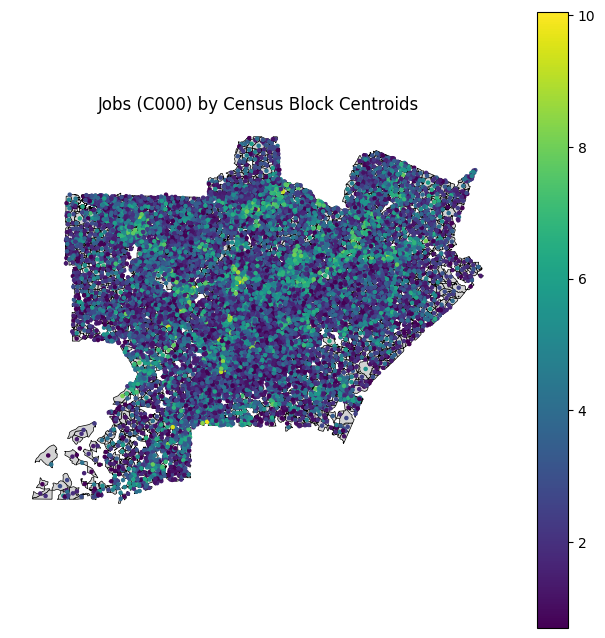

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))

gdf_lodes_blocks.plot(
    ax=ax,
    color='lightgray',
    edgecolor='black',
    linewidth=0.5
)

gdf_lodes_blocks.set_geometry("centroid").plot(
    ax=ax,
    column=np.log1p(gdf_lodes_blocks["C000"]),
    markersize=5,
    legend=True
)

ax.set_title("Jobs (C000) by Census Block Centroids")
ax.set_axis_off()

plt.show()

In [7]:
gdf_tracts = pygris.tracts(state=STATE, county=COUNTIES, year=YEAR)
gdf_tracts = erase_water(gdf_tracts)

# gdf_tracts['GEOID'] = gdf_tracts['GEOID'].astype(str)

# Calculate centroids
gdf_tracts = gdf_tracts.to_crs(epsg=3857)
gdf_tracts['centroid'] = gdf_tracts.geometry.centroid

Using FIPS code '13' for input 'GA'


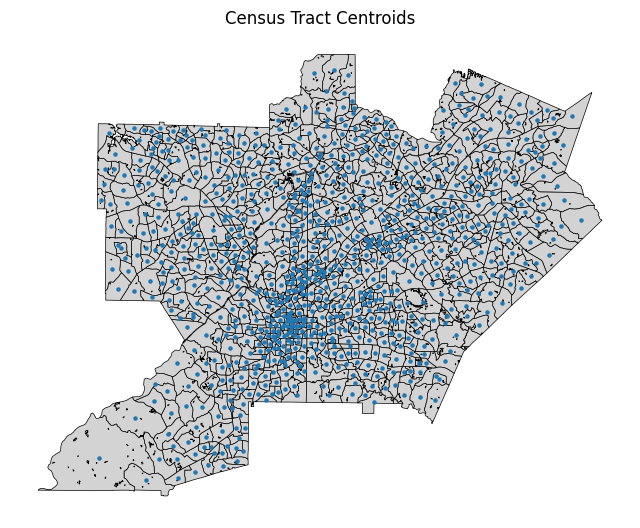

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))

gdf_tracts.plot(
    ax=ax,
    color='lightgray',
    edgecolor='black',
    linewidth=0.5
)

gdf_tracts.set_geometry("centroid").plot(
    ax=ax,
    markersize=5,
    legend=True
)

ax.set_title("Census Tract Centroids")
ax.set_axis_off()

plt.show()

In [9]:
transport_network = r5py.TransportNetwork(
    OSM_PBF,
    GTFS_FILES
)

In [10]:
origins = gdf_tracts.copy()
origins.geometry = origins.geometry.centroid

destinations = gdf_lodes_blocks.copy()
destinations.geometry = destinations.geometry.centroid

In [11]:
origins["id"] = origins["GEOID"]
destinations["id"] = destinations["w_geocode"]

In [ ]:
travel_time_matrix = r5py.TravelTimeMatrix(
    transport_network,
    origins=origins,
    destinations=destinations,
    transport_modes=[r5py.TransportMode.WALK, r5py.TransportMode.BICYCLE, r5py.TransportMode.TRANSIT],
    # transport_modes=[r5py.TransportMode.WALK, r5py.TransportMode.BICYCLE],
    departure=get_departure_time(GTFS_FILES),
    max_time=timedelta(minutes=60),
)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2091500579.py, line 7)

In [ ]:
travel_time_matrix.pivot(index="from_id", columns="to_id", values="travel_time")

In [ ]:
thresholds = [15, 30, 45, 60]

# Add jobs to OD matrix
ttm_jobs = travel_time_matrix.merge(
    gdf_lodes_blocks[['w_geocode', 'C000']],
    left_on='to_id',
    right_on='w_geocode',
    how='left'
)

ttm_jobs['C000'] = ttm_jobs['C000'].fillna(0)

accessibility = pd.DataFrame({
    'from_id': ttm_jobs['from_id'].unique()
})

for threshold in thresholds:
    reachable = ttm_jobs[ttm_jobs['travel_time'] <= threshold]

    jobs = (
        reachable.groupby('from_id')['C000']
        .sum()
        .reset_index(name=f'jobs_{threshold}min')
    )

    accessibility = accessibility.merge(
        jobs,
        on='from_id',
        how='left'
    )

# Replace NaNs with 0
accessibility = accessibility.fillna(0)

In [ ]:
threshold_cols = [
    "jobs_15min",
    "jobs_30min",
    "jobs_45min",
    "jobs_60min",
]

# Merge accessibility back to tract geometries
gdf_plot = gdf_tracts.merge(
    accessibility,
    left_on="GEOID",
    right_on="from_id",
    how="left"
)

gdf_plot[threshold_cols] = gdf_plot[threshold_cols].fillna(0)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

axes = axes.flatten()

for ax, col in zip(axes, threshold_cols):
    gdf_plot.plot(
        column=col,
        # scheme="quantiles",
        k=5,
        legend=True,
        ax=ax,
    )

    ax.set_title(col.replace("_", " "))
    ax.set_axis_off()

plt.tight_layout()
plt.show()

In [ ]:
# Create readable identifiers
county_str = "-".join(COUNTIES)
threshold_str = "-".join(map(str, thresholds))

# File name
filename = (
    f"accessibility_"
    f"state-{STATE}_"
    f"counties-{county_str}_"
    f"year-{YEAR}_"
    f"thresholds-{threshold_str}.parquet"
)

# Output folder
output_dir = Path("../data/processed_job_accessibility")
output_dir.mkdir(parents=True, exist_ok=True)

# Full path
filepath = output_dir / filename

# Save
accessibility.to_parquet(filepath, index=False)

print(filepath)